# Advanced DICOM Decoding with nvImageCodec

This notebook demonstrates advanced decoding techniques using the nvImageCodec API directly.

We'll explore:
- **Batch decoding** for improved throughput
- **GPU memory management** to avoid CPU copies
- **Performance comparison** across three approaches:
  1. pydicom without plugin (CPU)
  2. pydicom with nvImageCodec plugin (GPU, simple)
  3. Direct nvImageCodec API (GPU, advanced control)

The direct API approach is useful when you need fine-grained control over decoding, memory management, or want to integrate with GPU pipelines without CPU round-trips.


In [1]:
import os
import time
import numpy as np
import pydicom
from pydicom.data import get_testdata_file
from nvidia import nvimgcodec
from nvidia.nvimgcodec.tools.dicom import pydicom_plugin

# Load a multi-frame DICOM file from pydicom test data
# This file has compressed JPEG data with multiple frames (120 frames of 480x640 RGB)
test_file = get_testdata_file("examples_ybr_color.dcm")
print(f"Using test file: {test_file}")

# Check file info
ds_info = pydicom.dcmread(test_file, stop_before_pixels=True)
print(f"Transfer Syntax: {ds_info.file_meta.TransferSyntaxUID.name}")
print(f"Number of Frames: {ds_info.NumberOfFrames if hasattr(ds_info, 'NumberOfFrames') else 1}")
print(f"Image Size: {ds_info.Rows} x {ds_info.Columns}")
print()

Using test file: /home/janton/.local/lib/python3.10/site-packages/pydicom/data/test_files/examples_ybr_color.dcm
Transfer Syntax: JPEG Baseline (Process 1)
Number of Frames: 30
Image Size: 240 x 320



## Advanced Acceleration


When you load a DICOM file with a supported compressed transfer syntax and access `.pixel_array`, the nvImageCodec plugin automatically handles decoding on the GPU - no code changes needed! However, the acceleration here is limited due to the way that pydicom decode plugins work. The data needs to be returned as CPU memory, so in case that nvImageCodec outputs GPU memory, it needs to be copied back to the CPU, which adds overhead in case we wanted to consume it on the GPU. Also, nvImageCodec leverages batch processing for better utilization of resources, which can't be done with the pydicom plugin. That means, we need to decode frame by frame.

Another way to go beyond those limitations is invoking nvImageCodec directly, but it involves a little bit more code. Let's try to decode the same DICOM series in three different ways:

Let's compare three approaches:
1. **pydicom without plugin** (CPU only, default decoders)
2. **pydicom with plugin** (GPU-accelerated, copies back to CPU memory, and decodes frame by frame)
3. **nvImageCodec directly** (GPU-accelerated, batch processing - and no memory copy)

In [2]:
# 1. pydicom without plugin (CPU-only decoding)
print("Method 1: pydicom without plugin (CPU baseline)")
print("-" * 70)

start_time = time.time()
tries = 10
for _ in range(tries):
    ds = pydicom.dcmread(test_file)
    baseline_pixels = ds.pixel_array
baseline_time = (time.time() - start_time) / tries

num_frames = baseline_pixels.shape[0] if len(baseline_pixels.shape) > 2 else 1
print(f"✓ Decoded {num_frames} frames with pydicom (CPU)")
print(f"⏱️  Time: {baseline_time:.4f}s ({baseline_time/num_frames*1000:.2f} ms/frame)")
print(f"   Shape: {baseline_pixels.shape}")
print()

Method 1: pydicom without plugin (CPU baseline)
----------------------------------------------------------------------
✓ Decoded 30 frames with pydicom (CPU)
⏱️  Time: 0.1738s (5.79 ms/frame)
   Shape: (30, 240, 320, 3)



In [3]:
# 2. pydicom with nvImageCodec plugin (GPU-accelerated, but copies back to CPU)
print("Method 2: pydicom with nvImageCodec plugin (GPU → CPU)")
print("-" * 70)
from nvidia.nvimgcodec.tools.dicom.pydicom_plugin import SUPPORTED_DECODER_CLASSES
# Register the plugin for GPU acceleration
old_decoder_class_available = {}
for decoder_class in SUPPORTED_DECODER_CLASSES:
    old_decoder_class_available[decoder_class.UID] = decoder_class._available
    # Disable all decoder classes except nvjpeg2k
    decoder_class._available = {}

pydicom_plugin.register()

start_time = time.time()
tries = 10
for _ in range(tries):
    ds = pydicom.dcmread(test_file)
    plugin_pixels = ds.pixel_array
plugin_time = (time.time() - start_time) / tries

num_frames = plugin_pixels.shape[0] if len(plugin_pixels.shape) > 2 else 1
print(f"✓ Decoded {num_frames} frames with nvImageCodec plugin")
print(f"⏱️  Time: {plugin_time:.4f}s ({plugin_time/num_frames*1000:.2f} ms/frame)")
print(f"   Speedup over CPU: {baseline_time/plugin_time:.2f}x")
print(f"   Shape: {plugin_pixels.shape}")
print()

# Unregister plugin for next comparison
pydicom_plugin.unregister()
# Restore the old decoder class available status
for decoder_class in SUPPORTED_DECODER_CLASSES:
    decoder_class._available = old_decoder_class_available[decoder_class.UID]

Method 2: pydicom with nvImageCodec plugin (GPU → CPU)
----------------------------------------------------------------------
✓ Decoded 30 frames with nvImageCodec plugin
⏱️  Time: 0.0267s (0.89 ms/frame)
   Speedup over CPU: 6.50x
   Shape: (30, 240, 320, 3)



/home/janton/.local/lib/python3.10/site-packages/pydicom/pixels/decoders/base.py:302: UserWarning: The (0028,0004) 'Photometric Interpretation' value is 'RGB' however the encoded image's codestream contains a JFIF APP marker which indicates it should be 'YBR_FULL_422'
  warn_and_log(


In [4]:
# 3. nvImageCodec direct batch decoding (ADVANCED - maximum performance)
print("Method 3: nvImageCodec direct batch decoding (ADVANCED)")
print("-" * 70)
print("For maximum performance, decode all frames in one batch")
print("This avoids CPU memory copies and leverages batch processing\n")

# Load the file and extract encoded frames
ds = pydicom.dcmread(test_file)
encoded_frames = list(pydicom.encaps.generate_frames(ds.PixelData))

# Create decoder and decode all frames in one batch
decoder = nvimgcodec.Decoder()
decode_params = nvimgcodec.DecodeParams(
    allow_any_depth=True, 
    color_spec=nvimgcodec.ColorSpec.UNCHANGED
)

start_time = time.time()
tries = 10
for _ in range(tries):
    batch_decoded = decoder.decode(encoded_frames, params=decode_params)
batch_time = (time.time() - start_time) / tries

# Convert to CPU for comparison (but in practice you'd keep on GPU!)
batch_decoded_cpu = np.array([np.array(img.cpu()) for img in batch_decoded])

print(f"✓ Decoded {len(encoded_frames)} frames in one batch")
print(f"⏱️  Time: {batch_time:.4f}s ({batch_time/len(encoded_frames)*1000:.2f} ms/frame)")
print(f"   Speedup over CPU: {baseline_time/batch_time:.2f}x")
print(f"   Speedup over plugin: {plugin_time/batch_time:.2f}x")
print(f"   Shape: {batch_decoded_cpu.shape}")
print()

# Performance comparison
print("=" * 70)
print("PERFORMANCE SUMMARY")
print("=" * 70)
print(f"Method 1 (CPU baseline):     {baseline_time:.4f}s  ({baseline_time/num_frames*1000:.2f} ms/frame)")
print(f"Method 2 (plugin):           {plugin_time:.4f}s  ({plugin_time/num_frames*1000:.2f} ms/frame)  [{baseline_time/plugin_time:.2f}x faster]")
print(f"Method 3 (direct batch):     {batch_time:.4f}s  ({batch_time/num_frames*1000:.2f} ms/frame)  [{baseline_time/batch_time:.2f}x faster]")


Method 3: nvImageCodec direct batch decoding (ADVANCED)
----------------------------------------------------------------------
For maximum performance, decode all frames in one batch
This avoids CPU memory copies and leverages batch processing

✓ Decoded 30 frames in one batch
⏱️  Time: 0.0037s (0.12 ms/frame)
   Speedup over CPU: 47.39x
   Speedup over plugin: 7.29x
   Shape: (30, 240, 320, 3)

PERFORMANCE SUMMARY
Method 1 (CPU baseline):     0.1738s  (5.79 ms/frame)
Method 2 (plugin):           0.0267s  (0.89 ms/frame)  [6.50x faster]
Method 3 (direct batch):     0.0037s  (0.12 ms/frame)  [47.39x faster]


## Key Insights

- **Plugin approach** is the easiest - zero code changes but copies data to CPU
- **Direct API** is faster with batch processing and avoids CPU memory copies
- **For GPU pipelines**, keep data on GPU for maximum performance - no round-trips to CPU


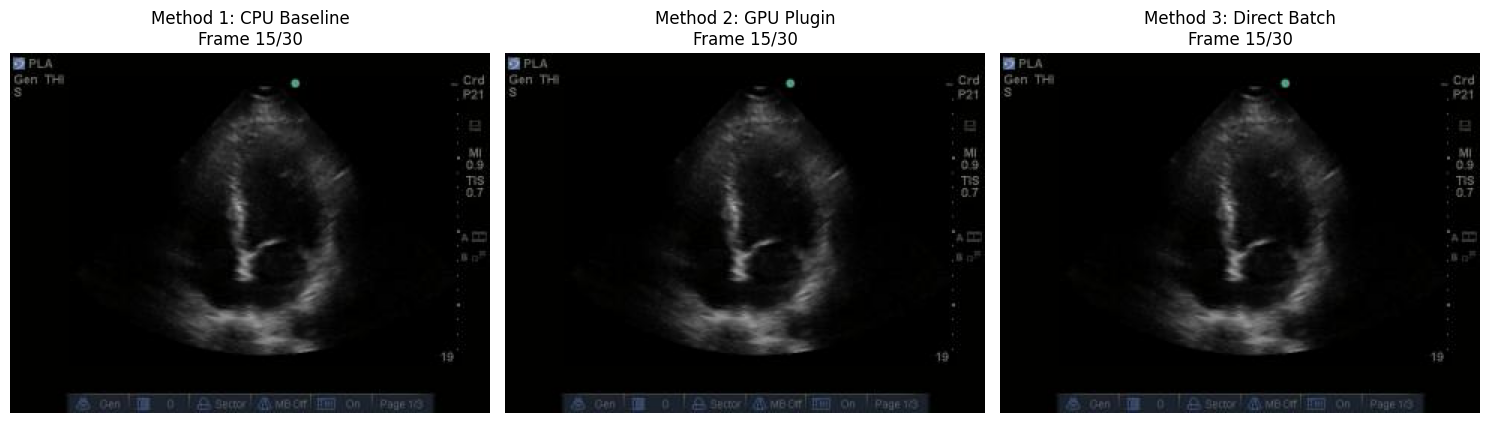

In [5]:
# Visual comparison of all three methods
import matplotlib.pyplot as plt

mid_idx = num_frames // 2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(baseline_pixels[mid_idx])
axes[0].set_title(f'Method 1: CPU Baseline\nFrame {mid_idx}/{num_frames}')
axes[0].axis('off')

axes[1].imshow(plugin_pixels[mid_idx])
axes[1].set_title(f'Method 2: GPU Plugin\nFrame {mid_idx}/{num_frames}')
axes[1].axis('off')

axes[2].imshow(batch_decoded_cpu[mid_idx])
axes[2].set_title(f'Method 3: Direct Batch\nFrame {mid_idx}/{num_frames}')
axes[2].axis('off')

plt.tight_layout()
plt.show()
